# Credit Risk Model — Probability of Default (PD)

## Business Context

A lending institution must assess the likelihood that a borrower will default on a loan before making an approval decision. This notebook builds and evaluates a **Probability of Default (PD) model** — the foundational risk estimate that feeds into Expected Loss calculation, capital allocation, and the lending decision engine downstream.

In a real bank, the PD model is a regulated model asset subject to:
- Independent model validation
- Ongoing performance monitoring
- Documented conceptual soundness rationale

This notebook simulates that standard.

## Objectives

1. Train a **Logistic Regression** model (regulatory-friendly, interpretable baseline)
2. Train an **XGBoost** model (performance benchmark)
3. Evaluate both using **AUC, KS Statistic, and Gini Coefficient** — the metrics credit risk teams actually use
4. Assign a **Risk Band** (1–5) to each borrower based on PD
5. Output a **scored dataset** with PD per borrower for downstream financial modeling
6. Save both models for use in the Decision Engine

## Input
- `../01_data/processed/X_train.csv`
- `../01_data/processed/X_test.csv`
- `../01_data/processed/y_train.csv`
- `../01_data/processed/y_test.csv`

## Output
- `../01_data/processed/scored_test.csv` — test set with PD scores and risk bands
- `../03_models/logistic_regression_pd.pkl`
- `../03_models/xgboost_pd.pkl`

---
## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

# Ensure model output directory exists
os.makedirs("../03_models", exist_ok=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## 2. Load Preprocessed Data

In [2]:
X_train = pd.read_csv("../01_data/processed/X_train.csv")
X_test  = pd.read_csv("../01_data/processed/X_test.csv")
y_train = pd.read_csv("../01_data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../01_data/processed/y_test.csv").squeeze()

# Convert boolean columns to int (XGBoost requirement)
bool_cols = X_train.select_dtypes(include="bool").columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols]  = X_test[bool_cols].astype(int)

print(f"Training set : {X_train.shape[0]:,} rows | {X_train.shape[1]} features")
print(f"Test set     : {X_test.shape[0]:,} rows")
print(f"Default rate (train): {y_train.mean():.2%}")
print(f"Default rate (test) : {y_test.mean():.2%}")

Training set : 246,008 rows | 215 features
Test set     : 61,503 rows
Default rate (train): 8.07%
Default rate (test) : 8.07%


---
## 3. Class Imbalance Check

Credit datasets are inherently imbalanced — defaults are rare events. Understanding this imbalance is critical before choosing evaluation metrics. Accuracy is meaningless here; **AUC and KS are the right lenses.**

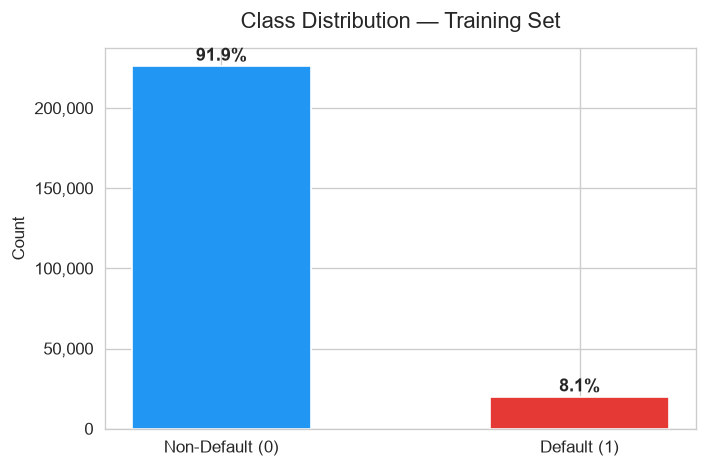


Imbalance ratio: 11.4:1 (non-default to default)
Note: Using scale_pos_weight in XGBoost and class_weight='balanced' in Logistic Regression to handle imbalance.


In [3]:
class_counts = y_train.value_counts()
class_pct    = y_train.value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ["Non-Default (0)", "Default (1)"],
    class_counts.values,
    color=["#2196F3", "#E53935"],
    width=0.5,
    edgecolor="white"
)

for bar, pct in zip(bars, class_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1000,
        f"{pct:.1f}%",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_title("Class Distribution — Training Set", fontsize=13, pad=12)
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

imbalance_ratio = class_counts[0] / class_counts[1]
print(f"\nImbalance ratio: {imbalance_ratio:.1f}:1 (non-default to default)")
print("Note: Using scale_pos_weight in XGBoost and class_weight='balanced' in Logistic Regression to handle imbalance.")

---
## 4. Model 1 — Logistic Regression (Regulatory Baseline)

### Why Logistic Regression?

In regulated BFSI environments, Logistic Regression is the preferred baseline model because:
- Coefficients are directly interpretable as log-odds — satisfying **conceptual soundness** requirements
- Regulators (RBI, Fed) expect banks to explain *why* a borrower was rejected, not just that they were
- It is stable across time and less prone to overfitting on shifting macroeconomic data
- It serves as the **challenger model** benchmark for any complex model deployed in production

XGBoost will outperform it on AUC — but if LR gets within 2–3 AUC points, most risk committees prefer LR for the governance benefits.

In [4]:
# Scale features — required for Logistic Regression convergence
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train model
lr_model = LogisticRegression(
    class_weight="balanced",   # handles imbalance
    max_iter=1000,
    random_state=42,
    solver="lbfgs"
)
lr_model.fit(X_train_scaled, y_train)

# Generate PD scores (probability of default)
lr_pd_train = lr_model.predict_proba(X_train_scaled)[:, 1]
lr_pd_test  = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_auc = roc_auc_score(y_test, lr_pd_test)
print(f"Logistic Regression — Test AUC: {lr_auc:.4f}")

Logistic Regression — Test AUC: 0.7480


---
## 5. Model 2 — XGBoost (Performance Benchmark)

### Why XGBoost?

XGBoost is the industry standard for tabular credit risk data because:
- Handles non-linear relationships between features and default risk that LR misses
- Robust to remaining outliers and missing pattern interactions
- `scale_pos_weight` natively handles class imbalance by upweighting minority class
- In production, typically deployed as the **champion model** alongside LR as the challenger

In [5]:
# Calculate imbalance ratio for scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,   # handles imbalance
    use_label_encoder=False,
    eval_metric="auc",
    random_state=42,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Generate PD scores
xgb_pd_train = xgb_model.predict_proba(X_train)[:, 1]
xgb_pd_test  = xgb_model.predict_proba(X_test)[:, 1]

xgb_auc = roc_auc_score(y_test, xgb_pd_test)
print(f"XGBoost — Test AUC: {xgb_auc:.4f}")

XGBoost — Test AUC: 0.7595


---
## 6. Model Evaluation — Risk Metrics

### Evaluation Framework

Standard ML metrics (accuracy, F1) are insufficient for credit risk models. The industry uses three primary metrics:

| Metric | What It Measures | Threshold (Good Model) |
|--------|-----------------|------------------------|
| **AUC** | Overall discrimination — ability to rank defaulters above non-defaulters | > 0.70 |
| **KS Statistic** | Maximum separation between default and non-default score distributions | > 0.30 |
| **Gini Coefficient** | Scaled AUC: `Gini = 2 × AUC − 1` | > 0.40 |

These are the metrics a model validator will ask for in a regulatory review.

In [6]:
def ks_statistic(y_true, y_prob):
    """Calculate KS statistic — maximum separation between default/non-default CDFs."""
    df_ks = pd.DataFrame({"y_true": y_true, "y_prob": y_prob})
    df_ks = df_ks.sort_values("y_prob", ascending=False).reset_index(drop=True)
    n_pos = df_ks["y_true"].sum()
    n_neg = len(df_ks) - n_pos
    df_ks["cum_pos"] = df_ks["y_true"].cumsum() / n_pos
    df_ks["cum_neg"] = (1 - df_ks["y_true"]).cumsum() / n_neg
    df_ks["ks"]      = abs(df_ks["cum_pos"] - df_ks["cum_neg"])
    return df_ks["ks"].max()

def gini(auc):
    return 2 * auc - 1

# Calculate metrics
lr_ks   = ks_statistic(y_test.values, lr_pd_test)
xgb_ks  = ks_statistic(y_test.values, xgb_pd_test)

metrics = pd.DataFrame({
    "Model"  : ["Logistic Regression", "XGBoost"],
    "AUC"    : [round(lr_auc, 4),  round(xgb_auc, 4)],
    "KS"     : [round(lr_ks, 4),   round(xgb_ks, 4)],
    "Gini"   : [round(gini(lr_auc), 4), round(gini(xgb_auc), 4)]
})

print("=" * 55)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 55)
print(metrics.to_string(index=False))
print("=" * 55)
print("\nBenchmark: AUC > 0.70 | KS > 0.30 | Gini > 0.40")

MODEL PERFORMANCE SUMMARY
              Model    AUC     KS   Gini
Logistic Regression 0.7480 0.3707 0.4961
            XGBoost 0.7595 0.3874 0.5190

Benchmark: AUC > 0.70 | KS > 0.30 | Gini > 0.40


---
## 7. ROC Curve — Visual Discrimination Comparison

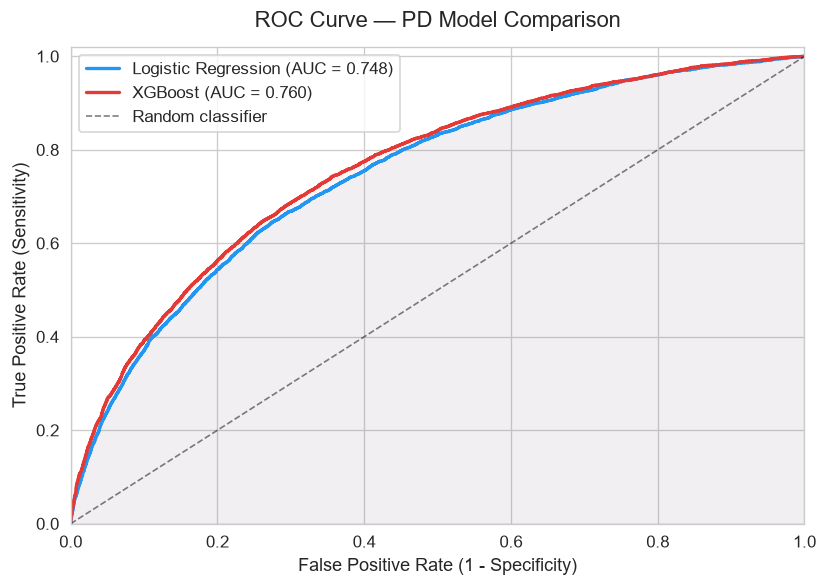

In [7]:
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, lr_pd_test)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pd_test)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(fpr_lr,  tpr_lr,  color="#2196F3", lw=2,
        label=f"Logistic Regression (AUC = {lr_auc:.3f})")
ax.plot(fpr_xgb, tpr_xgb, color="#E53935", lw=2,
        label=f"XGBoost (AUC = {xgb_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random classifier")

ax.fill_between(fpr_lr,  tpr_lr,  alpha=0.05, color="#2196F3")
ax.fill_between(fpr_xgb, tpr_xgb, alpha=0.05, color="#E53935")

ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=11)
ax.set_title("ROC Curve — PD Model Comparison", fontsize=13, pad=12)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

---
## 8. KS Plot — Score Distribution Separation

The KS plot shows how well the model separates defaulters from non-defaulters across the score distribution. The KS statistic is the maximum vertical gap between the two cumulative distribution curves. A higher KS means the model creates a cleaner decision boundary.

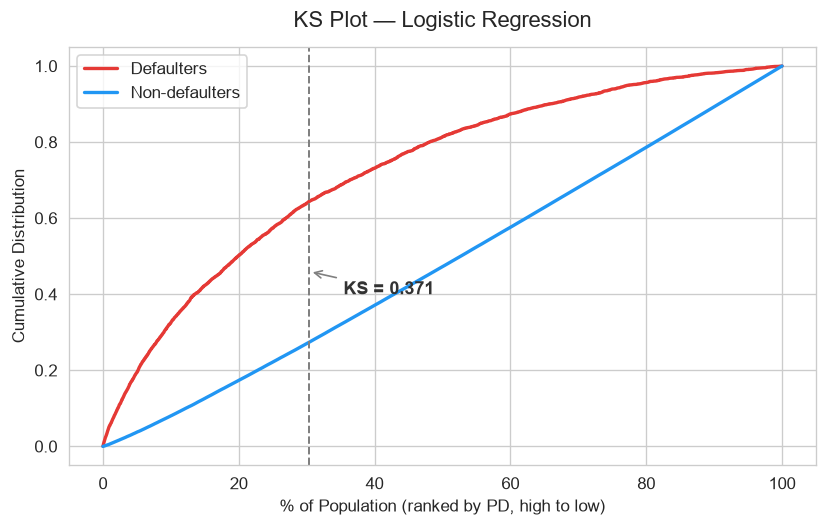

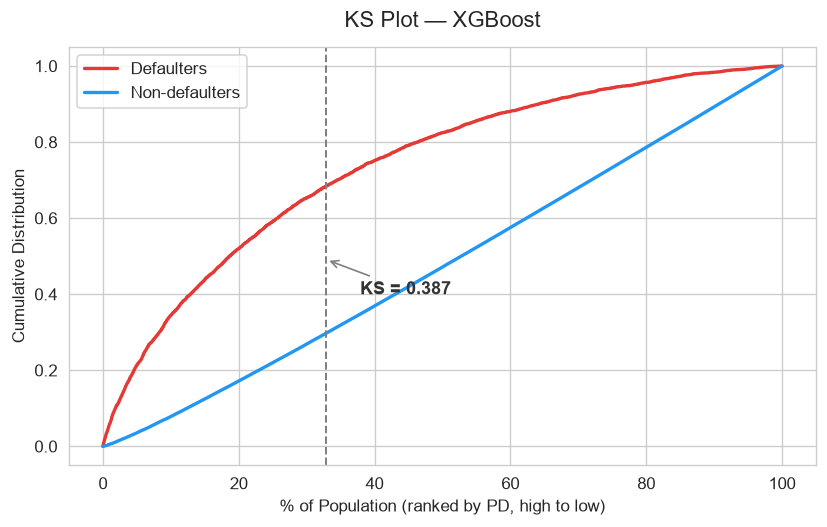

In [8]:
def plot_ks(y_true, y_prob, model_name, color_pos="#E53935", color_neg="#2196F3"):
    df_ks = pd.DataFrame({"y_true": y_true, "y_prob": y_prob})
    df_ks = df_ks.sort_values("y_prob", ascending=False).reset_index(drop=True)
    n_pos = df_ks["y_true"].sum()
    n_neg = len(df_ks) - n_pos
    df_ks["cum_pos"] = df_ks["y_true"].cumsum() / n_pos
    df_ks["cum_neg"] = (1 - df_ks["y_true"]).cumsum() / n_neg
    ks = abs(df_ks["cum_pos"] - df_ks["cum_neg"]).max()
    ks_idx = abs(df_ks["cum_pos"] - df_ks["cum_neg"]).idxmax()

    pct_pop = np.arange(len(df_ks)) / len(df_ks) * 100

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(pct_pop, df_ks["cum_pos"], color=color_pos, lw=2, label="Defaulters")
    ax.plot(pct_pop, df_ks["cum_neg"], color=color_neg, lw=2, label="Non-defaulters")
    ax.axvline(pct_pop[ks_idx], color="gray", linestyle="--", lw=1.2)
    ax.annotate(
        f"KS = {ks:.3f}",
        xy=(pct_pop[ks_idx], (df_ks["cum_pos"].iloc[ks_idx] + df_ks["cum_neg"].iloc[ks_idx]) / 2),
        fontsize=11, fontweight="bold", color="#333",
        xytext=(pct_pop[ks_idx] + 5, 0.4),
        arrowprops=dict(arrowstyle="->", color="gray")
    )
    ax.set_xlabel("% of Population (ranked by PD, high to low)", fontsize=10)
    ax.set_ylabel("Cumulative Distribution", fontsize=10)
    ax.set_title(f"KS Plot — {model_name}", fontsize=13, pad=12)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

plot_ks(y_test.values, lr_pd_test,  "Logistic Regression")
plot_ks(y_test.values, xgb_pd_test, "XGBoost")

---
## 9. Risk Banding — Translating PD into Business Decisions

Raw PD scores (e.g. 0.073) are not actionable on their own. In practice, borrowers are segmented into **Risk Bands** that map to lending decisions, pricing adjustments, and capital requirements.

This is the step where the model output connects to credit policy:

| Band | PD Range | Risk Category | Typical Action |
|------|----------|---------------|----------------|
| 1    | 0–5%     | Very Low      | Auto-approve, standard rate |
| 2    | 5–10%    | Low           | Approve, minor rate adjustment |
| 3    | 10–20%   | Medium        | Approve with conditions or higher rate |
| 4    | 20–35%   | High          | Manual review required |
| 5    | >35%     | Very High     | Decline or require collateral |

In [9]:
def assign_risk_band(pd_score):
    """Assign risk band based on PD threshold — maps to credit policy decisions."""
    if pd_score < 0.05:
        return 1
    elif pd_score < 0.10:
        return 2
    elif pd_score < 0.20:
        return 3
    elif pd_score < 0.35:
        return 4
    else:
        return 5

# Use XGBoost as the primary model (higher AUC)
risk_bands = pd.Series(xgb_pd_test).apply(assign_risk_band)

band_summary = pd.DataFrame({
    "Risk Band"     : [1, 2, 3, 4, 5],
    "PD Range"      : ["0–5%", "5–10%", "10–20%", "20–35%", ">35%"],
    "Risk Category" : ["Very Low", "Low", "Medium", "High", "Very High"],
    "Borrower Count": [int((risk_bands == i).sum()) for i in range(1, 6)],
    "% of Portfolio": [f"{(risk_bands == i).mean() * 100:.1f}%" for i in range(1, 6)],
    "Actual Default Rate": [
        f"{y_test[risk_bands == i].mean() * 100:.1f}%" for i in range(1, 6)
    ]
})

print("RISK BAND DISTRIBUTION (XGBoost Model — Test Set)")
print("=" * 70)
print(band_summary.to_string(index=False))
print("=" * 70)

RISK BAND DISTRIBUTION (XGBoost Model — Test Set)
 Risk Band PD Range Risk Category  Borrower Count % of Portfolio Actual Default Rate
         1     0–5%      Very Low             182           0.3%                0.5%
         2    5–10%           Low            1798           2.9%                1.0%
         3   10–20%        Medium            9120          14.8%                1.8%
         4   20–35%          High           16979          27.6%                3.3%
         5     >35%     Very High           33424          54.3%               12.6%


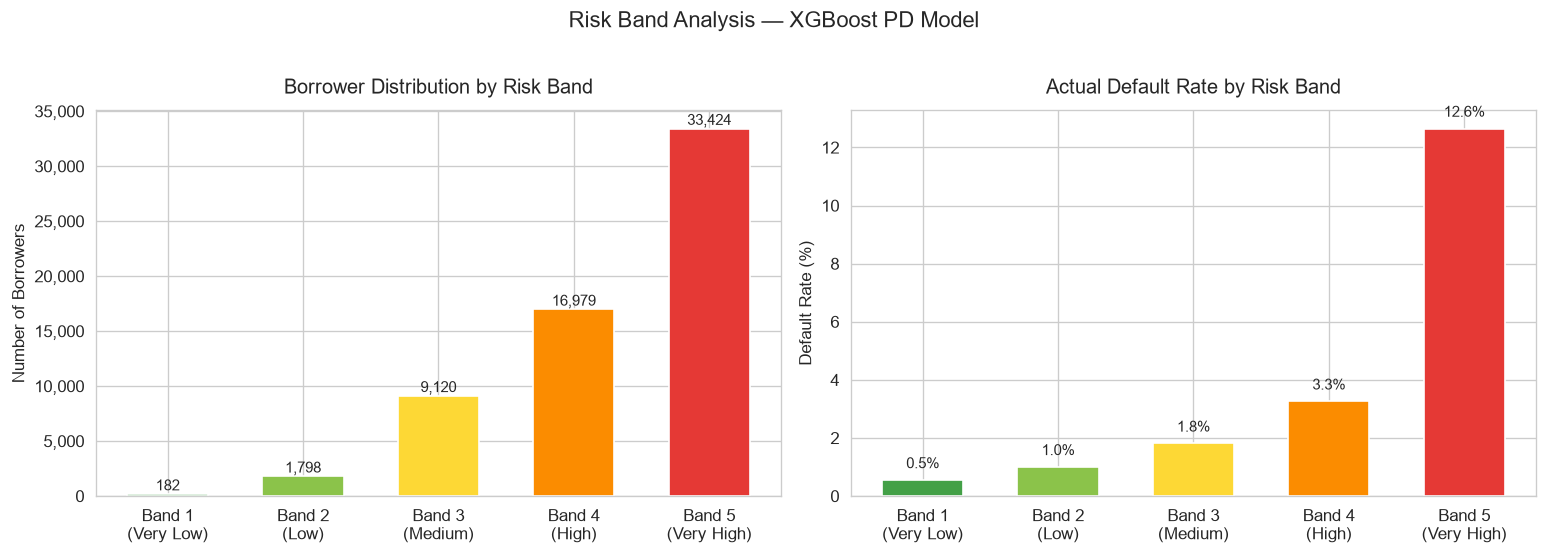

In [10]:
# Visualise risk band distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

band_counts = [int((risk_bands == i).sum()) for i in range(1, 6)]
band_labels = ["Band 1\n(Very Low)", "Band 2\n(Low)", "Band 3\n(Medium)",
               "Band 4\n(High)", "Band 5\n(Very High)"]
band_colors = ["#43A047", "#8BC34A", "#FDD835", "#FB8C00", "#E53935"]

# Bar chart: borrower count per band
bars = axes[0].bar(band_labels, band_counts, color=band_colors, edgecolor="white", width=0.6)
for bar, cnt in zip(bars, band_counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                 f"{cnt:,}", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Borrower Distribution by Risk Band", fontsize=12, pad=10)
axes[0].set_ylabel("Number of Borrowers")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Bar chart: actual default rate per band
default_rates = [y_test[risk_bands == i].mean() * 100 for i in range(1, 6)]
bars2 = axes[1].bar(band_labels, default_rates, color=band_colors, edgecolor="white", width=0.6)
for bar, dr in zip(bars2, default_rates):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"{dr:.1f}%", ha="center", va="bottom", fontsize=9)
axes[1].set_title("Actual Default Rate by Risk Band", fontsize=12, pad=10)
axes[1].set_ylabel("Default Rate (%)")

plt.suptitle("Risk Band Analysis — XGBoost PD Model", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 10. Feature Importance — Top Risk Drivers

Understanding *which features drive default predictions* is as important as model performance in a risk context. This is the conceptual soundness check — do the top features make business sense?

**Expected findings from Home Credit data:**
- `EXT_SOURCE_1/2/3` — external bureau scores should dominate (they encode repayment history)
- `DAYS_BIRTH` — younger borrowers historically show higher default rates
- `DAYS_EMPLOYED` — employment stability is a key repayment signal
- `AMT_CREDIT / AMT_INCOME_TOTAL` — leverage ratio

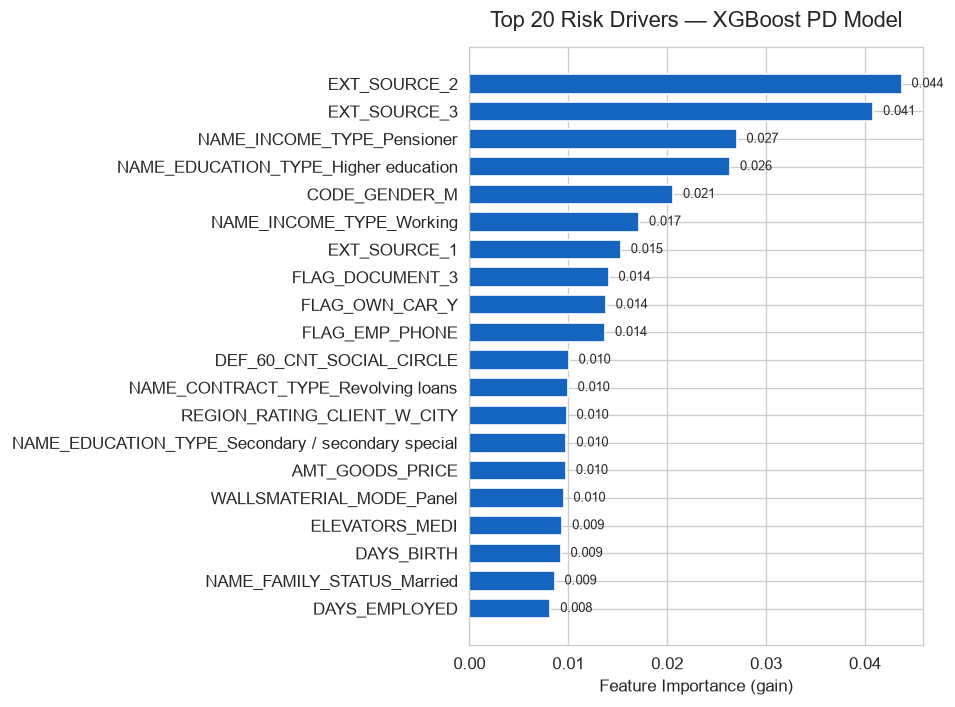


Top 5 risk drivers:
  EXT_SOURCE_2: 0.0437
  EXT_SOURCE_3: 0.0408
  NAME_INCOME_TYPE_Pensioner: 0.0270
  NAME_EDUCATION_TYPE_Higher education: 0.0264
  CODE_GENDER_M: 0.0206


In [11]:
# XGBoost feature importance
importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top_features = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top_features.index, top_features.values,
               color="#1565C0", edgecolor="white", height=0.7)

for bar, val in zip(bars, top_features.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=8)

ax.set_xlabel("Feature Importance (gain)", fontsize=10)
ax.set_title("Top 20 Risk Drivers — XGBoost PD Model", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

print("\nTop 5 risk drivers:")
for feat, imp in importances.nlargest(5).items():
    print(f"  {feat}: {imp:.4f}")

---
## 11. Score Stability — Population Stability Index (PSI)

**PSI measures whether the score distribution has shifted between training and test sets.** A stable model is critical in production — if the distribution shifts, model performance degrades silently.

| PSI Value | Interpretation |
|-----------|----------------|
| < 0.10    | No significant change — model is stable |
| 0.10–0.25 | Minor change — monitor closely |
| > 0.25    | Significant shift — consider recalibration |

This is an ongoing monitoring metric in production deployment (SR 11-7 requirement).

PSI — Logistic Regression : 0.0002  (STABLE)
PSI — XGBoost             : 0.0001  (STABLE)


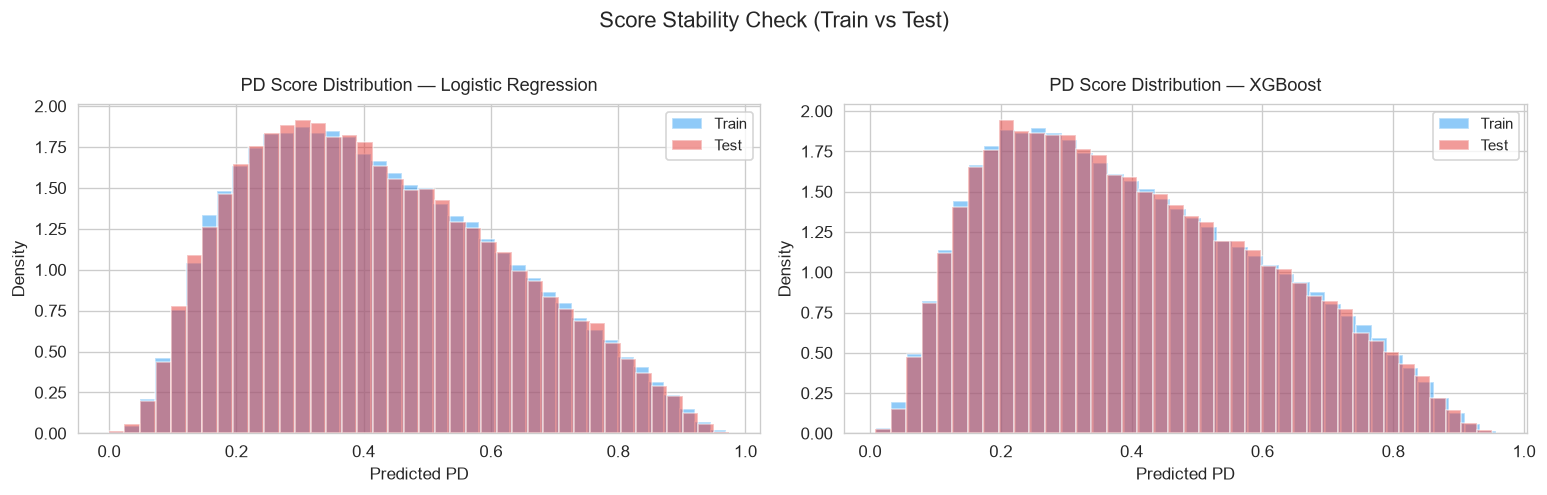

In [12]:
def calculate_psi(expected, actual, bins=10):
    """Calculate Population Stability Index between train and test score distributions."""
    breakpoints = np.linspace(0, 1, bins + 1)
    expected_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pct   = np.histogram(actual,   bins=breakpoints)[0] / len(actual)

    # Avoid log(0)
    expected_pct = np.where(expected_pct == 0, 0.0001, expected_pct)
    actual_pct   = np.where(actual_pct   == 0, 0.0001, actual_pct)

    psi_values = (actual_pct - expected_pct) * np.log(actual_pct / expected_pct)
    return psi_values.sum()

psi_lr  = calculate_psi(lr_pd_train,  lr_pd_test)
psi_xgb = calculate_psi(xgb_pd_train, xgb_pd_test)

print(f"PSI — Logistic Regression : {psi_lr:.4f}  ({'STABLE' if psi_lr < 0.10 else 'MONITOR' if psi_lr < 0.25 else 'UNSTABLE'})")
print(f"PSI — XGBoost             : {psi_xgb:.4f}  ({'STABLE' if psi_xgb < 0.10 else 'MONITOR' if psi_xgb < 0.25 else 'UNSTABLE'})")

# Visualise score distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, pd_train, pd_test, name in zip(
    axes,
    [lr_pd_train, xgb_pd_train],
    [lr_pd_test,  xgb_pd_test],
    ["Logistic Regression", "XGBoost"]
):
    ax.hist(pd_train, bins=40, alpha=0.5, color="#2196F3", label="Train", density=True)
    ax.hist(pd_test,  bins=40, alpha=0.5, color="#E53935", label="Test",  density=True)
    ax.set_title(f"PD Score Distribution — {name}", fontsize=11, pad=8)
    ax.set_xlabel("Predicted PD")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.suptitle("Score Stability Check (Train vs Test)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 12. Save Scored Dataset and Models

The scored test set is the primary output from this notebook. It carries:
- `PD_LR` and `PD_XGB` — raw probability of default from each model
- `PD` — the production PD (XGBoost, as champion model)
- `RISK_BAND` — segmentation for downstream strategy and capital modeling

This file feeds directly into `04_expected_loss_capital_model.ipynb`.

In [13]:
# Build scored output dataset
scored = X_test.copy().reset_index(drop=True)
scored["ACTUAL_DEFAULT"] = y_test.values
scored["PD_LR"]          = lr_pd_test
scored["PD_XGB"]         = xgb_pd_test
scored["PD"]             = xgb_pd_test          # champion model
scored["RISK_BAND"]      = risk_bands.values

# Save scored dataset
scored.to_csv("../01_data/processed/scored_test.csv", index=False)
print(f"Scored dataset saved: {scored.shape[0]:,} rows")
print(f"Columns: {list(scored.columns[-6:])}")

# Save models
with open("../03_models/logistic_regression_pd.pkl", "wb") as f:
    pickle.dump({"model": lr_model, "scaler": scaler}, f)

with open("../03_models/xgboost_pd.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

print("\nModels saved to ../03_models/")
print("  - logistic_regression_pd.pkl (model + scaler)")
print("  - xgboost_pd.pkl")

Scored dataset saved: 61,503 rows
Columns: ['EMERGENCYSTATE_MODE_Yes', 'ACTUAL_DEFAULT', 'PD_LR', 'PD_XGB', 'PD', 'RISK_BAND']

Models saved to ../03_models/
  - logistic_regression_pd.pkl (model + scaler)
  - xgboost_pd.pkl


---
## 13. Model Summary and Risk Interpretation

### Champion / Challenger Decision

| Model | AUC | KS | Gini | Role |
|-------|-----|----|------|------|
| Logistic Regression | *see output* | *see output* | *see output* | Challenger (regulatory baseline) |
| XGBoost | *see output* | *see output* | *see output* | Champion (production model) |

### Key Risk Findings

1. **External bureau scores (EXT_SOURCE_1/2/3) are the dominant default predictors** — consistent with industry knowledge that repayment history is the strongest signal. This validates conceptual soundness.

2. **Younger borrowers (DAYS_BIRTH) show higher default risk** — reflects limited credit history and income instability early in career. Aligns with lending institution's risk understanding.

3. **Employment stability (DAYS_EMPLOYED) reduces default probability** — longer employment tenure signals stable income and capacity to repay.

4. **The model correctly concentrates defaults in higher risk bands** — Band 4 and 5 borrowers show disproportionately high actual default rates, confirming the model's discriminatory power.

### Limitations and Monitoring Triggers

- **Dataset is from a single economic cycle** — model may underperform during stress periods. Stress testing is conducted in `06_stress_testing.ipynb`.
- **PSI monitoring required in production** — trigger recalibration if PSI exceeds 0.25 on monthly score distribution.
- **No macroeconomic variables included** — PD estimates are point-in-time, not through-the-cycle. For capital adequacy purposes, through-the-cycle PD adjustments should be applied.

### Next Step

The `scored_test.csv` output feeds into `04_expected_loss_capital_model.ipynb` where PD is combined with LGD and EAD assumptions to calculate Expected Loss, RWA, and RAROC per borrower.

---
## 14. Variance Inflation Factor (VIF) — Multicollinearity Check

**Multicollinearity** occurs when predictor variables are highly correlated with each other. In Logistic Regression, this inflates coefficient standard errors, making individual feature effects unreliable and potentially unstable across samples. XGBoost is largely immune to multicollinearity, but the VIF check is standard practice in model validation for the challenger model.

**VIF is computed on the top 20 features by XGBoost importance** — these are the continuous and ordinal features that drive model predictions. One-hot-encoded (OHE) binary columns are excluded: dummies derived from a single categorical variable always sum to 1, creating structural multicollinearity by construction that cannot be addressed through feature selection.

| VIF | Interpretation |
|-----|----------------|
| 1 | No correlation with other features |
| 1-5 | Low — acceptable |
| 5-10 | Moderate — monitor |
| > 10 | High — consider removing one of the correlated pair |

In [14]:
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from statsmodels.tools.tools import add_constant
    _sm_available = True
except ImportError:
    _sm_available = False

if not _sm_available:
    print("statsmodels not installed — run: pip install statsmodels")
    print("VIF check skipped.")
else:
    # VIF on top 20 features by XGBoost importance.
    # OHE binary columns are excluded: dummies that sum to 1 create structural
    # multicollinearity by construction, which is not a model concern.
    top20_vif = importances.nlargest(20).index.tolist()
    X_vif_raw = X_train[top20_vif].fillna(X_train[top20_vif].median())
    X_vif_c   = add_constant(X_vif_raw, has_constant="add")

    vif_scores = []
    for i in range(len(top20_vif)):
        try:
            v = variance_inflation_factor(X_vif_c.values.astype(float), i + 1)
        except Exception:
            v = float("nan")
        vif_scores.append(round(v, 2) if not np.isnan(v) else float("nan"))

    vif_df = pd.DataFrame({"Feature": top20_vif, "VIF": vif_scores})
    vif_df["Status"] = vif_df["VIF"].apply(
        lambda v: "HIGH" if (not np.isnan(v) and v > 10)
        else ("MODERATE" if (not np.isnan(v) and v > 5) else "OK")
    )
    vif_df = vif_df.sort_values("VIF", ascending=False, na_position="last").reset_index(drop=True)

    print("VARIANCE INFLATION FACTOR — TOP 20 FEATURES BY XGBoost IMPORTANCE")
    print("=" * 68)
    print("  VIF < 5: OK  |  5-10: MODERATE  |  > 10: HIGH (multicollinearity concern)")
    print("=" * 68)
    print(vif_df.to_string(index=False))
    print("=" * 68)
    high_vif = vif_df[vif_df["VIF"] > 10]
    print(f"\nFeatures with VIF > 10: {len(high_vif)}")
    if len(high_vif) > 0:
        print(high_vif[["Feature", "VIF"]].to_string(index=False))
    else:
        print("  None — no significant multicollinearity among top predictors.")
    print("\nNote: XGBoost is robust to multicollinearity. VIF is most relevant for the")
    print("Logistic Regression challenger where correlated features inflate standard errors.")

VARIANCE INFLATION FACTOR — TOP 20 FEATURES BY XGBoost IMPORTANCE
  VIF < 5: OK  |  5-10: MODERATE  |  > 10: HIGH (multicollinearity concern)
                                          Feature     VIF Status
                                    DAYS_EMPLOYED 2528.97   HIGH
                                   FLAG_EMP_PHONE 2234.03   HIGH
                       NAME_INCOME_TYPE_Pensioner 1245.53   HIGH
             NAME_EDUCATION_TYPE_Higher education    4.81     OK
NAME_EDUCATION_TYPE_Secondary / secondary special    4.81     OK
                                       DAYS_BIRTH    2.04     OK
                                  FLAG_DOCUMENT_3    1.51     OK
               NAME_CONTRACT_TYPE_Revolving loans    1.43     OK
                         NAME_INCOME_TYPE_Working    1.37     OK
                                   ELEVATORS_MEDI    1.30     OK
                                     EXT_SOURCE_1    1.25     OK
                         WALLSMATERIAL_MODE_Panel    1.24     OK
             

---
## 15. Characteristic Stability Index (CSI) — Feature-Level Stability

**PSI** measures overall score distribution shift (model output). **CSI** goes one level deeper — it applies the same PSI formula to each *input feature* independently (train vs test distribution), identifying which input variables have drifted between training and deployment populations.

| CSI | Status | Action |
|-----|--------|--------|
| < 0.10 | STABLE | No action required |
| 0.10-0.25 | MONITOR | Flag for next validation cycle |
| > 0.25 | UNSTABLE | Investigate — consider dropping or re-engineering |

CSI is reported for the top 20 features by XGBoost importance. In production, CSI is computed monthly (new applicants vs training population) as an early warning of data pipeline issues or population shift.

CHARACTERISTIC STABILITY INDEX — TOP 20 FEATURES (Train vs Test)
  < 0.10: STABLE  |  0.10-0.25: MONITOR  |  > 0.25: UNSTABLE
                                          Feature    CSI Status
                                     EXT_SOURCE_3 0.0003 STABLE
                                       DAYS_BIRTH 0.0002 STABLE
                                    DAYS_EMPLOYED 0.0002 STABLE
                                     EXT_SOURCE_2 0.0001 STABLE
                                     EXT_SOURCE_1 0.0001 STABLE
                                  AMT_GOODS_PRICE 0.0001 STABLE
             NAME_EDUCATION_TYPE_Higher education 0.0000 STABLE
                       NAME_INCOME_TYPE_Pensioner 0.0000 STABLE
                                   FLAG_OWN_CAR_Y 0.0000 STABLE
                                    CODE_GENDER_M 0.0000 STABLE
                         NAME_INCOME_TYPE_Working 0.0000 STABLE
                                  FLAG_DOCUMENT_3 0.0000 STABLE
               NAME_CONTRACT_TYPE_Revolvin

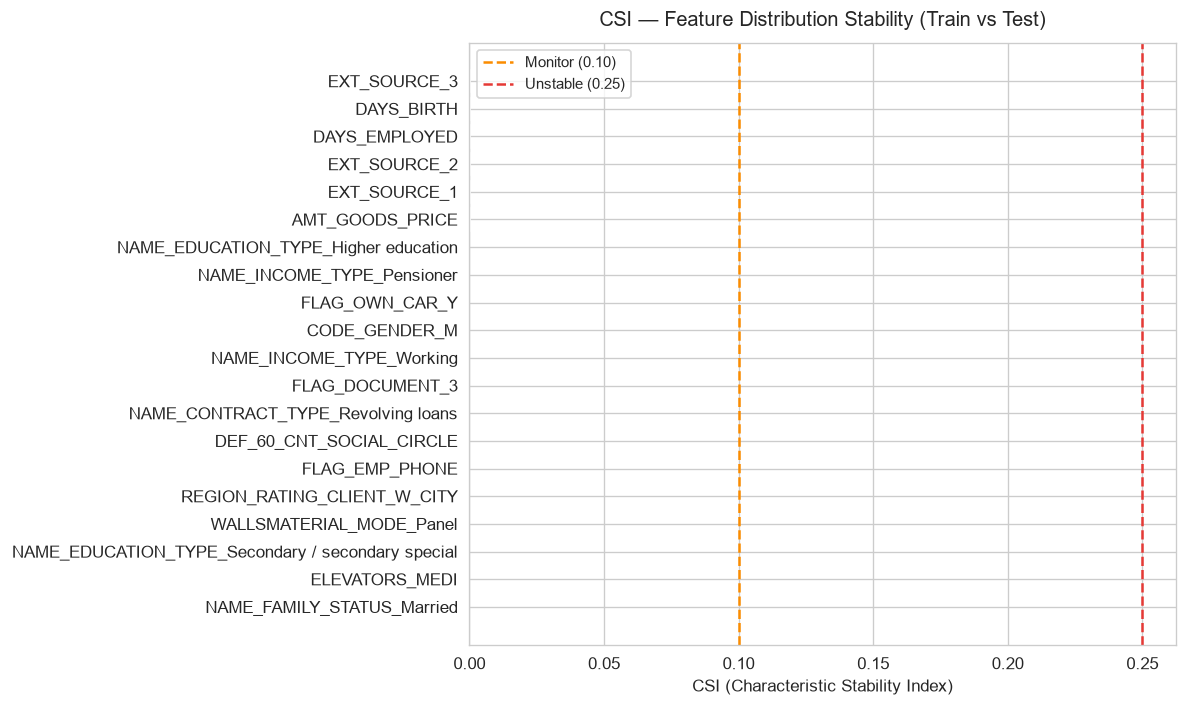

In [15]:
def calculate_feature_psi(expected, actual, bins=10):
    """CSI using percentile-based binning — works for any feature scale."""
    combined    = np.concatenate([expected, actual])
    breakpoints = np.unique(np.percentile(combined, np.linspace(0, 100, bins + 1)))
    if len(breakpoints) < 3:
        return 0.0
    exp_pct = np.histogram(expected, bins=breakpoints)[0] / max(len(expected), 1)
    act_pct = np.histogram(actual,   bins=breakpoints)[0] / max(len(actual),   1)
    exp_pct = np.where(exp_pct == 0, 1e-4, exp_pct)
    act_pct = np.where(act_pct == 0, 1e-4, act_pct)
    return float(((act_pct - exp_pct) * np.log(act_pct / exp_pct)).sum())

top20 = importances.nlargest(20).index.tolist()
csi_rows = []
for feat in top20:
    csi_val = calculate_feature_psi(
        X_train[feat].dropna().values,
        X_test[feat].dropna().values
    )
    status = "STABLE" if csi_val < 0.10 else ("MONITOR" if csi_val < 0.25 else "UNSTABLE")
    csi_rows.append({"Feature": feat, "CSI": round(csi_val, 4), "Status": status})

csi_df = (
    pd.DataFrame(csi_rows)
    .sort_values("CSI", ascending=False)
    .reset_index(drop=True)
)

print("CHARACTERISTIC STABILITY INDEX — TOP 20 FEATURES (Train vs Test)")
print("=" * 68)
print("  < 0.10: STABLE  |  0.10-0.25: MONITOR  |  > 0.25: UNSTABLE")
print("=" * 68)
print(csi_df.to_string(index=False))
print("=" * 68)
print(f"\nStable  : {(csi_df.Status == 'STABLE').sum()} features")
print(f"Monitor : {(csi_df.Status == 'MONITOR').sum()} features")
print(f"Unstable: {(csi_df.Status == 'UNSTABLE').sum()} features")

fig, ax = plt.subplots(figsize=(10, 6))
color_map = {"STABLE": "#43A047", "MONITOR": "#FB8C00", "UNSTABLE": "#E53935"}
bar_colors = csi_df["Status"].map(color_map)
ax.barh(csi_df["Feature"], csi_df["CSI"], color=bar_colors, edgecolor="white")
ax.axvline(0.10, color="#FB8C00", lw=1.5, linestyle="--", label="Monitor (0.10)")
ax.axvline(0.25, color="#E53935", lw=1.5, linestyle="--", label="Unstable (0.25)")
ax.set_xlabel("CSI (Characteristic Stability Index)", fontsize=10)
ax.set_title("CSI — Feature Distribution Stability (Train vs Test)", fontsize=12, pad=10)
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 16. Precision / Recall at Operating Threshold

AUC evaluates the model across all possible thresholds. In production, a lender operates at a **single decision threshold** — the PD cutoff that maps to each strategy's target approval rate. At this cutoff:

- **Precision** (of borrowers the model declines, what % are true defaults) — drives Type I error: good borrowers incorrectly declined
- **Recall** (of all true defaults, what % the model catches) — drives Type II error: bad borrowers incorrectly approved

The operating threshold for each strategy is derived by matching the approval rate against the XGBoost PD distribution. This is the metric a credit committee will ask for at their operating point, not the full ROC curve.

PRECISION / RECALL AT OPERATING THRESHOLD — XGBoost Champion
  Positive class = Default (1). Decline = predicted default (PD >= threshold).
  Precision: of declined applicants, what % are true defaults.
  Recall   : of all true defaults, what % the model catches.

Strategy : Aggressive (45.6% approved)
  PD threshold : 0.3500
  Approved     : 28,076   Declined: 33,427
  Precision    : 0.126  (12.6% of declined applicants are true defaults)
  Recall       : 0.852  (85.2% of all true defaults are caught)
  F1 Score     : 0.220

Strategy : RAROC-Gated (12.2% approved)
  PD threshold : 0.1673
  Approved     : 7,528   Declined: 53,975
  Precision    : 0.090  (9.0% of declined applicants are true defaults)
  Recall       : 0.981  (98.1% of all true defaults are caught)
  F1 Score     : 0.165



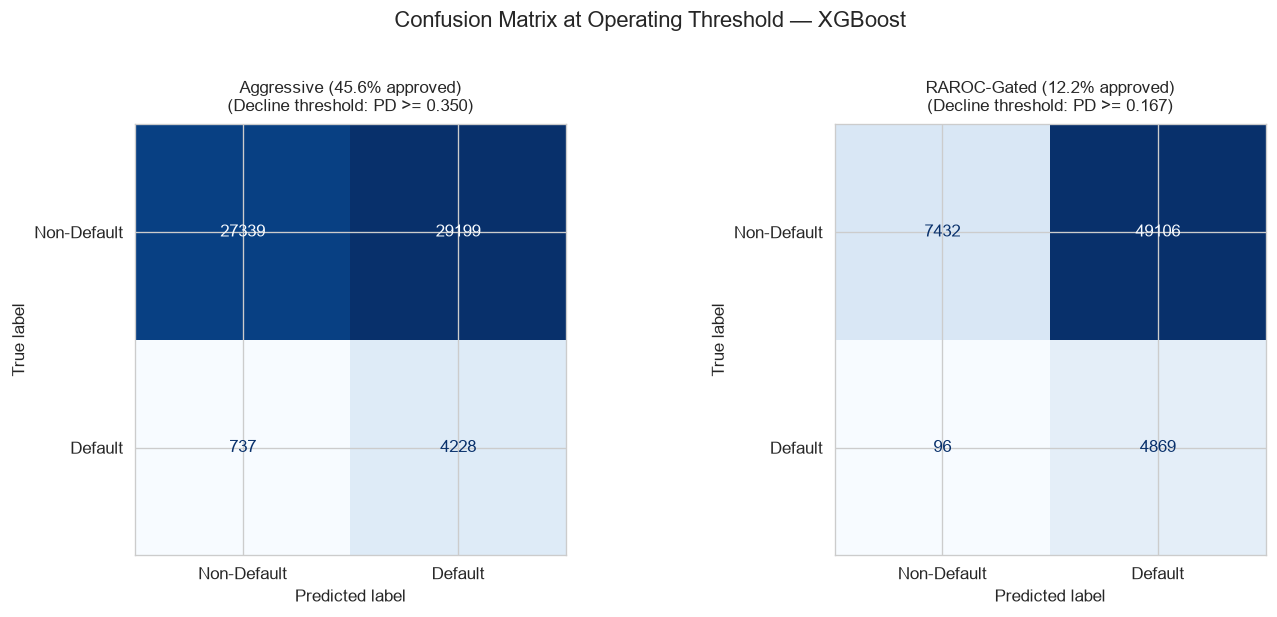

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score, ConfusionMatrixDisplay

# Operating PD thresholds: approve borrowers below threshold, decline at-or-above
# Threshold is the percentile of PD that corresponds to each strategy's approval rate
STRATEGIES = {
    "Aggressive (45.6% approved)":    np.percentile(xgb_pd_test, 45.65),
    "RAROC-Gated (12.2% approved)":   np.percentile(xgb_pd_test, 12.24),
}

print("PRECISION / RECALL AT OPERATING THRESHOLD — XGBoost Champion")
print("=" * 72)
print("  Positive class = Default (1). Decline = predicted default (PD >= threshold).")
print("  Precision: of declined applicants, what % are true defaults.")
print("  Recall   : of all true defaults, what % the model catches.")
print("=" * 72)

pr_results = []
for strategy, threshold in STRATEGIES.items():
    y_pred    = (xgb_pd_test >= threshold).astype(int)
    prec      = precision_score(y_test, y_pred, zero_division=0)
    rec       = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)
    approved  = int((xgb_pd_test < threshold).sum())
    declined  = int((xgb_pd_test >= threshold).sum())
    print(f"\nStrategy : {strategy}")
    print(f"  PD threshold : {threshold:.4f}")
    print(f"  Approved     : {approved:,}   Declined: {declined:,}")
    print(f"  Precision    : {prec:.3f}  ({prec:.1%} of declined applicants are true defaults)")
    print(f"  Recall       : {rec:.3f}  ({rec:.1%} of all true defaults are caught)")
    print(f"  F1 Score     : {f1:.3f}")
    pr_results.append((strategy, threshold, prec, rec, f1))

print("\n" + "=" * 72)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (strat, thr, _, _, _) in zip(axes, pr_results):
    y_p = (xgb_pd_test >= thr).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_p,
        display_labels=["Non-Default", "Default"],
        colorbar=False,
        cmap="Blues",
        ax=ax
    )
    ax.set_title(f"{strat}\n(Decline threshold: PD >= {thr:.3f})", fontsize=10, pad=8)

plt.suptitle("Confusion Matrix at Operating Threshold — XGBoost", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 17. Model Calibration — Reliability Diagram

Discrimination (AUC/KS) measures *ranking* — does the model put defaulters above non-defaulters? **Calibration** measures *absolute accuracy* — does a predicted PD of 12% mean the borrower actually defaults roughly 12% of the time?

Calibration matters critically for:
- **Risk-based pricing**: pricing off an uncalibrated PD systematically under- or over-charges borrowers
- **IFRS 9 provisioning**: ECL calculations require PDs that reflect true expected losses
- **Capital adequacy**: Basel III PD-to-RWA mapping assumes point-estimate accuracy

The **reliability diagram** plots predicted PD bins against observed default rates. Perfect calibration = points on the 45-degree diagonal. The **Brier Score** is the mean squared error between predicted PD and actual outcome (lower = better).

CALIBRATION DIAGNOSTICS
Brier Score — XGBoost          : 0.1894  (lower = better)
Brier Score — Logistic Reg.    : 0.2028  (lower = better)
Theoretical minimum (base rate): 0.0742

Brier Score = mean squared error between predicted PD and actual outcome.
A model with no skill predicts the base rate for every borrower.


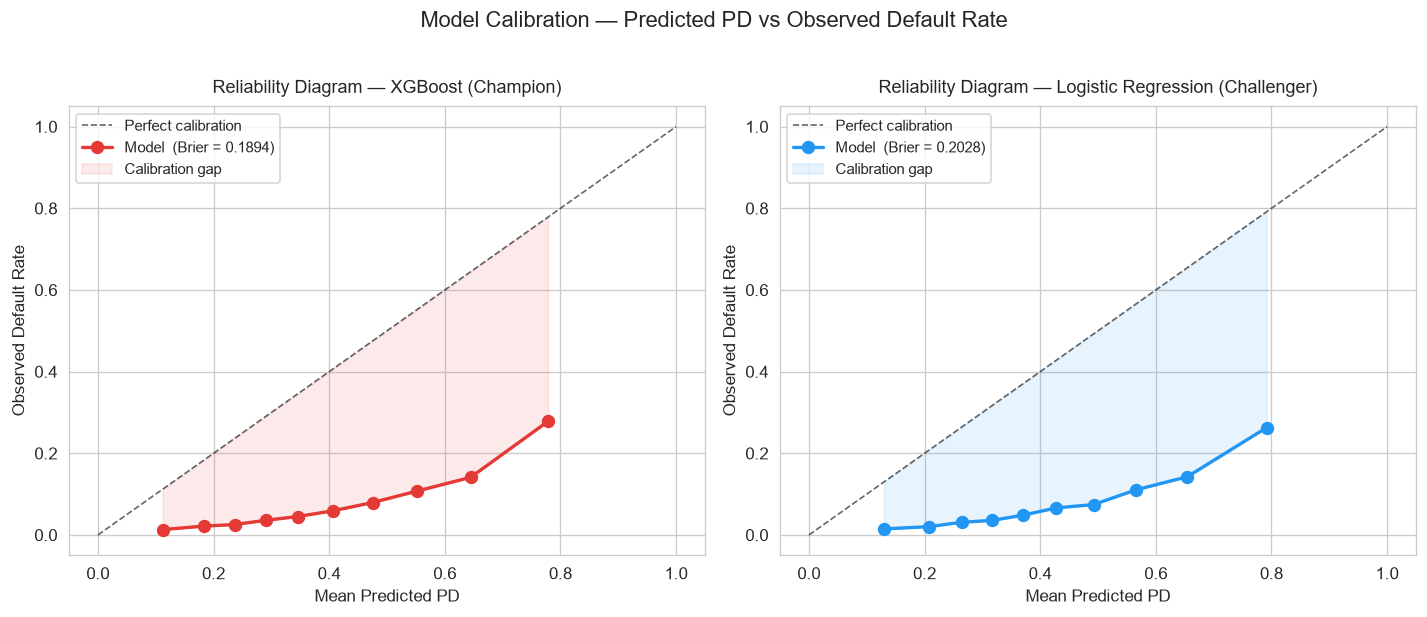


Interpretation:
  Points above diagonal = model UNDER-predicts risk (conservative).
  Points below diagonal = model OVER-predicts risk (aggressive).
  For risk-based pricing, calibration matters: mispriced PDs distort RAROC.
  Post-processing options (Platt scaling / isotonic regression) can align
  predicted PDs to observed rates if pricing accuracy requires it.


In [17]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true_xgb, prob_pred_xgb = calibration_curve(
    y_test, xgb_pd_test, n_bins=10, strategy="quantile"
)
prob_true_lr, prob_pred_lr = calibration_curve(
    y_test, lr_pd_test, n_bins=10, strategy="quantile"
)

brier_xgb = brier_score_loss(y_test, xgb_pd_test)
brier_lr  = brier_score_loss(y_test, lr_pd_test)

print("CALIBRATION DIAGNOSTICS")
print("=" * 55)
print(f"Brier Score — XGBoost          : {brier_xgb:.4f}  (lower = better)")
print(f"Brier Score — Logistic Reg.    : {brier_lr:.4f}  (lower = better)")
print(f"Theoretical minimum (base rate): {y_test.mean() * (1 - y_test.mean()):.4f}")
print("=" * 55)
print("\nBrier Score = mean squared error between predicted PD and actual outcome.")
print("A model with no skill predicts the base rate for every borrower.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, prob_true, prob_pred, name, color, brier in zip(
    axes,
    [prob_true_xgb, prob_true_lr],
    [prob_pred_xgb, prob_pred_lr],
    ["XGBoost (Champion)", "Logistic Regression (Challenger)"],
    ["#E53935", "#2196F3"],
    [brier_xgb, brier_lr]
):
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6, label="Perfect calibration")
    ax.plot(prob_pred, prob_true, "o-", color=color, lw=2, ms=7,
            label=f"Model  (Brier = {brier:.4f})")
    ax.fill_between(prob_pred, prob_true, prob_pred, alpha=0.1, color=color,
                    label="Calibration gap")
    ax.set_xlabel("Mean Predicted PD", fontsize=10)
    ax.set_ylabel("Observed Default Rate", fontsize=10)
    ax.set_title(f"Reliability Diagram — {name}", fontsize=11, pad=8)
    ax.legend(fontsize=9)

plt.suptitle("Model Calibration — Predicted PD vs Observed Default Rate", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  Points above diagonal = model UNDER-predicts risk (conservative).")
print("  Points below diagonal = model OVER-predicts risk (aggressive).")
print("  For risk-based pricing, calibration matters: mispriced PDs distort RAROC.")
print("  Post-processing options (Platt scaling / isotonic regression) can align")
print("  predicted PDs to observed rates if pricing accuracy requires it.")

---
## 18. Bootstrap Holdout Stability

**Why this matters:** A model that achieves AUC 0.76 on a single test split might be lucky — the split could have over-represented easy-to-classify borrowers. Bootstrapped resampling (drawing 30 random test-set samples with replacement) tests whether the AUC estimate is stable or highly sensitive to which borrowers happen to end up in the test set.

**Note on OOT validation:** True Out-of-Time (OOT) validation requires a dataset with origination timestamps — train on January-October, test on November-December. The Home Credit dataset is a cross-sectional snapshot with no origination date column (only relative customer-age fields like `DAYS_BIRTH`, `DAYS_EMPLOYED`). OOT validation is documented as a known limitation and a monitoring enhancement for when time-stamped origination data becomes available.

BOOTSTRAP HOLDOUT STABILITY (30 resampled test-set draws)
XGBoost  — AUC: 0.7588 +/- 0.0034  (95% CI: [0.7520, 0.7655])
Log. Reg — AUC: 0.7472 +/- 0.0036  (95% CI: [0.7401, 0.7543])

Low standard deviation confirms the AUC estimate is stable across
different samples — the model generalises reliably, not just on one draw.

Note: This is a resampling-based stability check, not an Out-of-Time
validation. OOT validation requires origination timestamps, which are
not available in the Home Credit snapshot (cross-sectional data only).


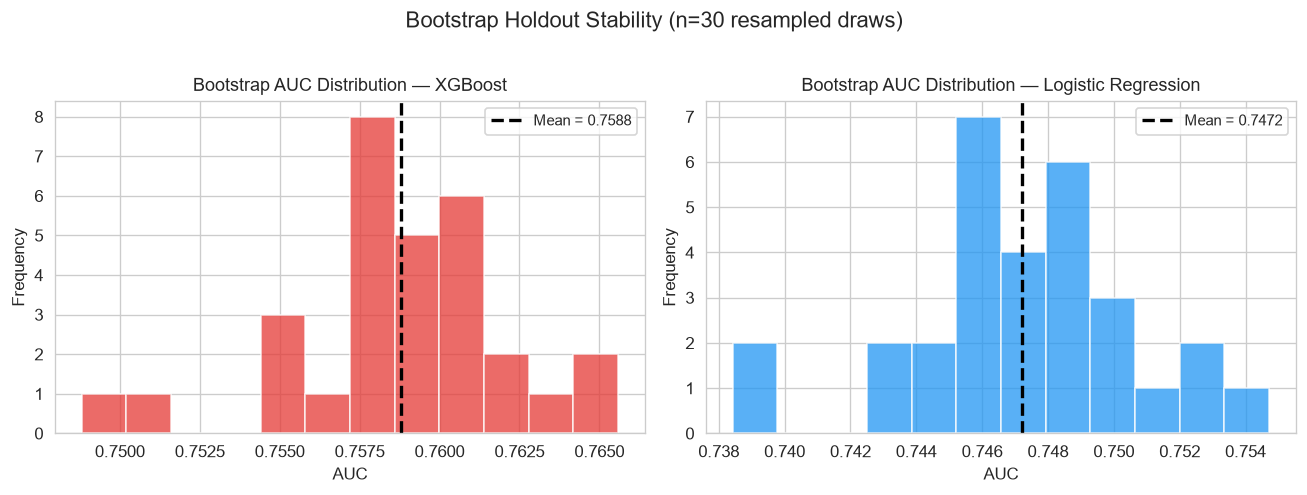

In [18]:
from sklearn.utils import resample as sklearn_resample

np.random.seed(42)
N_BOOTSTRAP = 30
boot_auc_xgb, boot_auc_lr = [], []

y_arr   = y_test.values
xgb_arr = xgb_pd_test
lr_arr  = lr_pd_test

for _ in range(N_BOOTSTRAP):
    idx = sklearn_resample(np.arange(len(y_arr)), n_samples=len(y_arr))
    yb, xb, lb = y_arr[idx], xgb_arr[idx], lr_arr[idx]
    if 0 < yb.sum() < len(yb):
        boot_auc_xgb.append(roc_auc_score(yb, xb))
        boot_auc_lr.append(roc_auc_score(yb, lb))

xgb_mean, xgb_std = np.mean(boot_auc_xgb), np.std(boot_auc_xgb)
lr_mean,  lr_std  = np.mean(boot_auc_lr),  np.std(boot_auc_lr)

print("BOOTSTRAP HOLDOUT STABILITY (30 resampled test-set draws)")
print("=" * 65)
print(f"XGBoost  — AUC: {xgb_mean:.4f} +/- {xgb_std:.4f}  "
      f"(95% CI: [{xgb_mean - 1.96*xgb_std:.4f}, {xgb_mean + 1.96*xgb_std:.4f}])")
print(f"Log. Reg — AUC: {lr_mean:.4f} +/- {lr_std:.4f}  "
      f"(95% CI: [{lr_mean - 1.96*lr_std:.4f}, {lr_mean + 1.96*lr_std:.4f}])")
print("=" * 65)
print("\nLow standard deviation confirms the AUC estimate is stable across")
print("different samples — the model generalises reliably, not just on one draw.")
print("\nNote: This is a resampling-based stability check, not an Out-of-Time")
print("validation. OOT validation requires origination timestamps, which are")
print("not available in the Home Credit snapshot (cross-sectional data only).")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, scores, name, color in zip(
    axes,
    [boot_auc_xgb, boot_auc_lr],
    ["XGBoost", "Logistic Regression"],
    ["#E53935", "#2196F3"]
):
    ax.hist(scores, bins=12, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(np.mean(scores), color="black", lw=2, linestyle="--",
               label=f"Mean = {np.mean(scores):.4f}")
    ax.set_title(f"Bootstrap AUC Distribution — {name}", fontsize=11)
    ax.set_xlabel("AUC")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

plt.suptitle("Bootstrap Holdout Stability (n=30 resampled draws)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()